Daily and Annualized Returns Calculation

In [3]:
import numpy as np
import pandas as pd
from pathlib import Path
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
WORKSPACE_DIR = Path(r"C:\Users\P LIKITH VARMA\OneDrive\Desktop\mutual_fund_analtics\mutual_fund_analytics_platform")
DB_PATH = WORKSPACE_DIR /"db" / "bluestock_mf.db" # Adjusted path or use sqlite3.connect check

# 2. Extract and join NAV with Fund Master directly from SQLite
try:
    conn = sqlite3.connect(DB_PATH)
    query = "SELECT date, amfi_code, nav FROM fact_nav ORDER BY date;"
    df_nav = pd.read_sql_query(query, conn)
    conn.close()
except Exception:
    # Safe fallback if executing directly outside the structural path layout
    df_nav_raw = pd.read_csv(WORKSPACE_DIR / "data" / "02_nav_history.csv")

# Ensure dates are explicitly formatted as time-series dimensions
df_nav_raw['date'] = pd.to_datetime(df_nav_raw['date'])


In [7]:
# 2. Pivot the data to wide-format (Dates as rows, Fund Codes as columns)
df_prices = df_nav_raw.pivot(index='date', columns='amfi_code', values='nav').sort_index()



In [8]:
# 3. Compute Daily Returns: daily_return = (nav_t / nav_t-1) - 1
df_daily_returns = df_prices.pct_change()

# 4. Compute Annualized Returns across the complete historical horizon
# Formula: Annualized Return = ((1 + daily_return).prod() ** (252 / n)) - 1
n_days = len(df_prices)
annualized_returns = ((1 + df_daily_returns).prod() ** (252 / n_days)) - 1

In [ ]:
# 5. Convert findings into a clean, exportable summary DataFrame
df_returns_summary = pd.DataFrame({
    'annualized_return': annualized_returns
}).reset_index()

# Export Task 1 output to CSV inside your working directory
output_path_t1 = WORKSPACE_DIR / "outputs" / "returns_computed.csv"
output_path_t1.parent.mkdir(parents=True, exist_ok=True)
df_returns_summary.to_csv(output_path_t1, index=False)

print("📌 --- STATISTICAL SAMPLER ---")
print(f"Total days analyzed (n): {n_days}")
print(df_returns_summary.head(3))
print(f"\n Returns exported to {output_path_t1}")

📌 --- STATISTICAL SAMPLER ---
Total days analyzed (n): 1150
   amfi_code  annualized_return
0     100016           0.025412
1     100025           0.042948
2     100033           0.288994

✅ Success: complete! Returns exported to C:\Users\P LIKITH VARMA\OneDrive\Desktop\mutual_fund_analtics\mutual_fund_analytics_platform\outputs\returns_computed.csv


Calculating Compounded Annual Growth Rate (CAGR) for 1-Year, 3-Year, and 5-Year horizons

In [10]:
# 1. Ensure the price matrix index is explicitly sorted by date
df_prices = df_prices.sort_index()

In [11]:
# 2. Extract end NAV values (Latest available date in May 2026)
latest_date = df_prices.index.max()
nav_latest = df_prices.loc[latest_date]

In [12]:
# 3. Define target historical baseline dates looking backward from the peak
date_1yr_ago = latest_date - pd.DateOffset(years=1)
date_3yr_ago = latest_date - pd.DateOffset(years=3)
date_start = df_prices.index.min() # Max inception boundary (Jan 2022)

In [13]:
# 4. Helper function to find the closest matching trading day in the index
def get_closest_nav(target_date):
    closest_idx = df_prices.index.get_indexer([target_date], method='pad')[0]
    if closest_idx == -1: # Fallback forward if pad fails
        closest_idx = df_prices.index.get_indexer([target_date], method='bfill')[0]
    return df_prices.iloc[closest_idx]

# Extract baseline historical values
nav_1yr = get_closest_nav(date_1yr_ago)
nav_3yr = get_closest_nav(date_3yr_ago)
nav_base = df_prices.iloc[0] # Earliest available point

In [14]:
# 5. Compute CAGR calculations
cagr_1yr = (nav_latest / nav_1yr) ** (1 / 1.0) - 1
cagr_3yr = (nav_latest / nav_3yr) ** (1 / 3.0) - 1

# Calculate lifetime horizon years dynamically (approx 4.4 years from Jan 2022 to May 2026)
horizon_years = (latest_date - date_start).days / 365.25
cagr_max_horizon = (nav_latest / nav_base) ** (1 / horizon_years) - 1

In [17]:
df_cagr = pd.DataFrame({
    'cagr_1yr': cagr_1yr,
    'cagr_3yr': cagr_3yr,
    f'cagr_{int(round(horizon_years))}yr_horizon': cagr_max_horizon
}).reset_index()

# Fetch scheme details directly from SQL database to avoid NameError
try:
    df_funds_raw = pd.read_sql_query("SELECT amfi_code, scheme_name, category FROM dim_fund;", conn)
except Exception:
    df_funds_raw = pd.read_csv(WORKSPACE_DIR / "data" / "01_fund_master.csv")

# Merge fields together seamlessly
df_cagr_report = pd.merge(df_cagr, df_funds_raw, on='amfi_code', how='inner')

# Organize columns for peak corporate scannability
df_cagr_report = df_cagr_report[['amfi_code', 'scheme_name', 'category', 'cagr_1yr', 'cagr_3yr', f'cagr_{int(round(horizon_years))}yr_horizon']]

In [ ]:
# 7. Export file to the processed data warehouse tier
output_path_t2 = WORKSPACE_DIR / "outputs"/ "cagr_report.csv"
df_cagr_report.to_csv(output_path_t2, index=False)

print("📌 --- TASK 2 STATISTICAL CAGR SAMPLER ---")
print(df_cagr_report.head(5).to_string(formatters={
    'cagr_1yr': '{:,.2%}'.format,
    'cagr_3yr': '{:,.2%}'.format,
    f'cagr_{int(round(horizon_years))}yr_horizon': '{:,.2%}'.format
}))
print(f"\n CAGR report written to {output_path_t2}")

📌 --- TASK 2 STATISTICAL CAGR SAMPLER ---
   amfi_code                                         scheme_name category cagr_1yr cagr_3yr cagr_4yr_horizon
0     100016           HDFC Top 100 Fund - Regular Plan - Growth   Equity   -2.22%    1.29%            2.64%
1     100025        HDFC Short Term Debt Fund - Regular - Growth     Debt    3.70%    3.92%            4.46%
2     100033  HDFC Mid-Cap Opportunities Fund - Regular - Growth   Equity   53.23%   32.44%           30.12%
3     101206       ABSL Frontline Equity Fund - Regular - Growth   Equity   47.92%   28.97%           23.54%
4     101207              ABSL Small Cap Fund - Regular - Growth   Equity  -23.99%   -4.15%            7.94%

✅ Success: Task 2 complete! CAGR report written to C:\Users\P LIKITH VARMA\OneDrive\Desktop\mutual_fund_analtics\mutual_fund_analytics_platform\outputs\cagr_report.csv


Computing the Sharpe Ratio

In [22]:
# 1. Define foundational constant parameters
RISK_FREE_RATE = 0.065  # 6.5% RBI Repo Rate Proxy

# 2. Extract annualized return vector from your existing Task 1 summary DataFrame
# Setting amfi_code as index to easily perform vectorized matrix subtraction
df_ret_idx = df_returns_summary.set_index('amfi_code')

In [23]:
# 3. Calculate the annualized volatility (Standard Deviation) for each column scheme
# Annualization multiplier for daily standard deviation is sqrt(252)
daily_std = df_daily_returns.std()
annualized_volatility = daily_std * np.sqrt(252)

# 4. Compute vectorized Sharpe Ratio: (Annualized Return - Risk Free Rate) / Annualized Volatility
sharpe_ratios = (df_ret_idx['annualized_return'] - RISK_FREE_RATE) / annualized_volatility

In [24]:
# 5. Build final reporting dataset and merge structural scheme descriptors from database
df_sharpe = pd.DataFrame({
    'annualized_volatility': annualized_volatility,
    'sharpe_ratio': sharpe_ratios
}).reset_index()

df_sharpe_report = pd.merge(df_sharpe, df_funds_raw[['amfi_code', 'scheme_name', 'category']], on='amfi_code', how='inner')

# Organize columns cleanly
df_sharpe_report = df_sharpe_report[['amfi_code', 'scheme_name', 'category', 'annualized_volatility', 'sharpe_ratio']]

In [ ]:
# 6. Export file to your local processed data folder
output_path_t3 = WORKSPACE_DIR / "outputs"/ "sharpe_values.csv"
df_sharpe_report.to_csv(output_path_t3, index=False)

print("📌 ---  STATISTICAL SHARPE RATIO SAMPLER ---")
print(df_sharpe_report.sort_values(by='sharpe_ratio', ascending=False).head(5).to_string(formatters={
    'annualized_volatility': '{:,.2%}'.format,
    'sharpe_ratio': '{:,.4f}'.format
}))
print(f"\n  Sharpe values written to {output_path_t3}")

📌 ---  STATISTICAL SHARPE RATIO SAMPLER ---
    amfi_code                                    scheme_name category annualized_volatility sharpe_ratio
34     148567  Mirae Asset Large Cap Fund - Regular - Growth   Equity                14.19%       1.6354
30     120843         Kotak Flexicap Fund - Regular - Growth   Equity                15.89%       1.4571
36     148569  Mirae Asset Tax Saver Fund - Regular - Growth   Equity                17.67%       1.3660
19     119551      SBI Bluechip Fund - Regular Plan - Growth   Equity                13.74%       1.3297
25     120505       ICICI Pru Midcap Fund - Regular - Growth   Equity                19.29%       1.2950

✅ Success: complete! Sharpe values written to C:\Users\P LIKITH VARMA\OneDrive\Desktop\mutual_fund_analtics\mutual_fund_analytics_platform\outputs\sharpe_values.csv


Computing the Sortino Ratio

In [26]:
# 1. Isolate down-market days (replace positive returns with 0 or NaN to isolate downside risk)
df_downside_returns = df_daily_returns.copy()
df_downside_returns[df_downside_returns > 0] = np.nan # Focus strictly on negative deviation days

In [28]:
# 2. Calculate Annualized Downside Deviation (Downside Volatility)
# Multiplied by sqrt(252) to scale up to annual standard
downside_std = df_downside_returns.std()
annualized_downside_vol = downside_std * np.sqrt(252)

# 3. Compute vectorized Sortino Ratio: (Annualized Return - Risk Free Rate) / Annualized Downside Volatility
sortino_ratios = (df_ret_idx['annualized_return'] - RISK_FREE_RATE) / annualized_downside_vol

In [29]:
# 4. Build final reporting table and merge with structural schema details
df_sortino = pd.DataFrame({
    'annualized_downside_volatility': annualized_downside_vol,
    'sortino_ratio': sortino_ratios
}).reset_index()

df_sortino_report = pd.merge(df_sortino, df_funds_raw[['amfi_code', 'scheme_name', 'category']], on='amfi_code', how='inner')

# Organize columns cleanly
df_sortino_report = df_sortino_report[['amfi_code', 'scheme_name', 'category', 'annualized_downside_volatility', 'sortino_ratio']]

In [ ]:
# 5. Export file to your local processed data warehouse tier
output_path_t4 = WORKSPACE_DIR / "outputs" / "sortino_values.csv"
df_sortino_report.to_csv(output_path_t4, index=False)

print("📌 ---  STATISTICAL SORTINO RATIO SAMPLER ---")
print(df_sortino_report.sort_values(by='sortino_ratio', ascending=False).head(5).to_string(formatters={
    'annualized_downside_volatility': '{:,.2%}'.format,
    'sortino_ratio': '{:,.4f}'.format
}))
print(f"\n Sortino values written to {output_path_t4}")

📌 ---  STATISTICAL SORTINO RATIO SAMPLER ---
    amfi_code                                    scheme_name category annualized_downside_volatility sortino_ratio
34     148567  Mirae Asset Large Cap Fund - Regular - Growth   Equity                          8.62%        2.6938
30     120843         Kotak Flexicap Fund - Regular - Growth   Equity                          8.78%        2.6363
36     148569  Mirae Asset Tax Saver Fund - Regular - Growth   Equity                         10.17%        2.3748
19     119551      SBI Bluechip Fund - Regular Plan - Growth   Equity                          7.76%        2.3554
25     120505       ICICI Pru Midcap Fund - Regular - Growth   Equity                         11.22%        2.2269

✅ Success:  complete! Sortino values written to C:\Users\P LIKITH VARMA\OneDrive\Desktop\mutual_fund_analtics\mutual_fund_analytics_platform\outputs\sortino_values.csv


Computing Alpha and Beta via Benchmark Regression

In [34]:
from scipy.stats import linregress

# 1. Fetch benchmark index daily records
try:
    query_bench = "SELECT * FROM fact_benchmark_indices ORDER BY date;"
    df_bench_raw = pd.read_sql_query(query_bench, conn)
except Exception:
    # Try alternate location chains if paths differ locally
    try:
        df_bench_raw = pd.read_csv(WORKSPACE_DIR / "data" / "10_benchmark_indices.csv")
    except Exception:
        df_bench_raw = pd.read_csv(WORKSPACE_DIR / "10_benchmark_indices.csv")

# Ensure date format mapping matches perfectly
df_bench_raw['date'] = pd.to_datetime(df_bench_raw['date'])

In [35]:
# 2. Dynamically determine the correct column names to avoid KeyErrors
columns_list = df_bench_raw.columns.tolist()

# Find which column contains the index name (usually 'index_name' or 'benchmark')
index_col = [c for c in columns_list if 'name' in c or 'bench' in c or 'index' in c][0]

# Find which column contains the price data (bypassing 'date' and the index column string)
numeric_cols = df_bench_raw.select_dtypes(include=[np.number]).columns.tolist()
if len(numeric_cols) == 1:
    price_col = numeric_cols[0]
else:
    price_col = [c for c in numeric_cols if 'close' in c or 'price' in c or 'val' in c or 'nav' in c][0]

In [36]:
# 3. Pivot benchmark data safely using the dynamically identified columns
df_bench_pivot = df_bench_raw.pivot(index='date', columns=index_col, values=price_col).sort_index()
df_bench_returns = df_bench_pivot.pct_change()

# Select our default market benchmark baseline array
benchmark_col = 'NIFTY 100 TRI' if 'NIFTY 100 TRI' in df_bench_returns.columns else df_bench_returns.columns[0]
series_bench = df_bench_returns[benchmark_col]

In [37]:
# 4. Align time-series records to ensure identical data points
df_returns_aligned = df_daily_returns.loc[df_daily_returns.index.isin(series_bench.index)]
series_bench_aligned = series_bench.loc[series_bench.index.isin(df_returns_aligned.index)]

In [38]:
# 5. Loop through every fund scheme and calculate the linear regression variables
alpha_beta_records = []

for amfi_code in df_returns_aligned.columns:
    fund_series = df_returns_aligned[amfi_code]
    
    # Drop rows where data points are missing (NaN)
    valid_mask = fund_series.notna() & series_bench_aligned.notna()
    
    if valid_mask.sum() > 30: # Ensure adequate sample size for math significance
        slope, intercept, r_value, p_value, std_err = linregress(
            series_bench_aligned[valid_mask], 
            fund_series[valid_mask]
        )
        
        # Scale daily intercept parameters up to annualized performance specifications
        # Alpha = intercept * 252 trading days
        annualized_alpha = intercept * 252
        beta = slope
        
        alpha_beta_records.append({
            'amfi_code': amfi_code,
            'alpha': annualized_alpha,
            'beta': beta,
            'r_squared': r_value ** 2
        })

In [39]:
# 6. Build final reporting dataframe and merge descriptive titles
df_ab = pd.DataFrame(alpha_beta_records)
df_ab_report = pd.merge(df_ab, df_funds_raw[['amfi_code', 'scheme_name', 'category']], on='amfi_code', how='inner')

# Organize layout columns cleanly
df_ab_report = df_ab_report[['amfi_code', 'scheme_name', 'category', 'alpha', 'beta', 'r_squared']]

In [ ]:
# 7. Export file to local data layer
output_path_t5 = WORKSPACE_DIR / "outputs" / "alpha_beta.csv"
df_ab_report.to_csv(output_path_t5, index=False)

print(f"📌 ---  REGRESSION SUMMARY (Benchmark: {benchmark_col}) ---")
print(df_ab_report.sort_values(by='alpha', ascending=False).head(5).to_string(formatters={
    'alpha': '{:,.2%}'.format,
    'beta': '{:,.3f}'.format,
    'r_squared': '{:,.2%}'.format
}))
print(f"\n Alpha/Beta values written to {output_path_t5}")

📌 ---  REGRESSION SUMMARY (Benchmark: BSE_SMALLCAP) ---
    amfi_code                                    scheme_name category  alpha   beta r_squared
21     119598     SBI Small Cap Fund - Regular Plan - Growth   Equity 31.51% -0.048     0.18%
25     120505       ICICI Pru Midcap Fund - Regular - Growth   Equity 29.81% -0.021     0.06%
39     149324          DSP Small Cap Fund - Regular - Growth   Equity 29.35%  0.029     0.06%
36     148569  Mirae Asset Tax Saver Fund - Regular - Growth   Equity 28.31%  0.001     0.00%
30     120843         Kotak Flexicap Fund - Regular - Growth   Equity 27.20%  0.002     0.00%

✅ Success: complete! Alpha/Beta values written to C:\Users\P LIKITH VARMA\OneDrive\Desktop\mutual_fund_analtics\mutual_fund_analytics_platform\outputs\alpha_beta.csv


Computing Maximum Drawdown (Max DD)

In [41]:
# 1. Compute the running peak (cumulative maximum price) for every single fund column over time
df_peaks = df_prices.cummax()

# 2. Calculate daily drawdown percentages relative to the running peak
df_drawdowns = (df_prices / df_peaks) - 1

# 3. Extract the lowest value (maximum drop) achieved for each fund
max_drawdowns = df_drawdowns.min()

In [42]:
# 4. Build final reporting dataset and merge descriptive titles from database
df_mdd = pd.DataFrame({
    'max_drawdown': max_drawdowns
}).reset_index()

df_mdd_report = pd.merge(df_mdd, df_funds_raw[['amfi_code', 'scheme_name', 'category']], on='amfi_code', how='inner')

# Organize layout columns cleanly
df_mdd_report = df_mdd_report[['amfi_code', 'scheme_name', 'category', 'max_drawdown']]

In [ ]:
# 5. Export file to local data layer
output_path_t6 = WORKSPACE_DIR / "outputs" / "max_drawdown.csv"
df_mdd_report.to_csv(output_path_t6, index=False)

print("📌 ---  STATISTICAL MAX DRAWDOWN SAMPLER ---")
# Sorting ascending to see the worst hits (largest negative values) first
print(df_mdd_report.sort_values(by='max_drawdown', ascending=True).head(5).to_string(formatters={
    'max_drawdown': '{:,.2%}'.format
}))
print(f"\n Max Drawdown report written to {output_path_t6}")

📌 ---  STATISTICAL MAX DRAWDOWN SAMPLER ---
    amfi_code                                 scheme_name category max_drawdown
22     119599   SBI Small Cap Fund - Direct Plan - Growth   Equity      -52.57%
17     119095      Axis Small Cap Fund - Regular - Growth   Equity      -51.68%
4      101207      ABSL Small Cap Fund - Regular - Growth   Equity      -35.45%
39     149324       DSP Small Cap Fund - Regular - Growth   Equity      -31.17%
21     119598  SBI Small Cap Fund - Regular Plan - Growth   Equity      -28.71%

✅ Success:  complete! Max Drawdown report written to C:\Users\P LIKITH VARMA\OneDrive\Desktop\mutual_fund_analtics\mutual_fund_analytics_platform\outputs\max_drawdown.csv


Building the Composite Fund Scorecard Model

In [44]:
# 1. Load all independently computed metric layers from the processed folder
df_cagr_layer  = pd.read_csv(WORKSPACE_DIR / "outputs" / "cagr_report.csv")
df_sharpe_layer = pd.read_csv(WORKSPACE_DIR / "outputs" / "sharpe_values.csv")
df_alpha_layer  = pd.read_csv(WORKSPACE_DIR / "outputs" / "alpha_beta.csv")
df_mdd_layer    = pd.read_csv(WORKSPACE_DIR / "outputs" / "max_drawdown.csv")

In [46]:
# 2. Fetch the expense ratios from your active SQL database connection
try:
    df_fees = pd.read_sql_query("SELECT amfi_code, expense_ratio_pct FROM dim_fund;", conn)
except Exception:
    df_fees = pd.read_csv(WORKSPACE_DIR / "data" / "01_fund_master.csv")[['amfi_code', 'expense_ratio_pct']]

In [47]:
# 3. Successively merge all layers onto a unified scorecard staging dataframe
df_scorecard = df_cagr_layer[['amfi_code', 'scheme_name', 'category', 'cagr_3yr']].copy()
df_scorecard = df_scorecard.merge(df_sharpe_layer[['amfi_code', 'sharpe_ratio']], on='amfi_code', how='inner')
df_scorecard = df_scorecard.merge(df_alpha_layer[['amfi_code', 'alpha']], on='amfi_code', how='inner')
df_scorecard = df_scorecard.merge(df_mdd_layer[['amfi_code', 'max_drawdown']], on='amfi_code', how='inner')
df_scorecard = df_scorecard.merge(df_fees, on='amfi_code', how='inner')

In [48]:
# 4. Standardize relative ranks using percentile positions (0.0 to 1.0)
# Higher raw numbers get higher percentile ranks
df_scorecard['rank_return'] = df_scorecard['cagr_3yr'].rank(pct=True)
df_scorecard['rank_sharpe'] = df_scorecard['sharpe_ratio'].rank(pct=True)
df_scorecard['rank_alpha']  = df_scorecard['alpha'].rank(pct=True)

# Inverse Rankings: Lower numbers represent lower costs/losses, which deserve a HIGHER rank score
df_scorecard['rank_expense'] = df_scorecard['expense_ratio_pct'].rank(pct=True, ascending=False)
df_scorecard['rank_mdd']     = df_scorecard['max_drawdown'].rank(pct=True, ascending=False)

In [49]:
# 5. Execute Weighted Matrix Summation to compute the final Composite Score (0 - 100 scale)
df_scorecard['composite_score'] = (
    (df_scorecard['rank_return']  * 0.30) +
    (df_scorecard['rank_sharpe']  * 0.25) +
    (df_scorecard['rank_alpha']   * 0.20) +
    (df_scorecard['rank_expense'] * 0.15) +
    (df_scorecard['rank_mdd']     * 0.10)
) * 100

# Sort the master catalog from best to worst performing funds
df_scorecard = df_scorecard.sort_values(by='composite_score', ascending=False).reset_index(drop=True)

# Isolate clean presentation columns for our final production deliverable
df_final_scorecard = df_scorecard[[
    'amfi_code', 'scheme_name', 'category', 'cagr_3yr', 'sharpe_ratio', 
    'alpha', 'expense_ratio_pct', 'max_drawdown', 'composite_score'
]]

In [ ]:
# 6. Export file to local data warehouse layer
output_path_t7 = WORKSPACE_DIR / "outputs" / "fund_scorecard.csv"
df_final_scorecard.to_csv(output_path_t7, index=False)

print("📌 ---  MASTER FUND SCORECARD LEADERBOARD (TOP 5) ---")
print(df_final_scorecard.head(5).to_string(formatters={
    'cagr_3yr': '{:,.2%}'.format,
    'sharpe_ratio': '{:,.3f}'.format,
    'alpha': '{:,.2%}'.format,
    'expense_ratio_pct': '{:,.2f}%'.format,
    'max_drawdown': '{:,.2%}'.format,
    'composite_score': '{:,.2f}'.format
}))
print(f"\n Integrated Scorecard model compiled at {output_path_t7}")

📌 ---  MASTER FUND SCORECARD LEADERBOARD (TOP 5) ---
   amfi_code                                         scheme_name category cagr_3yr sharpe_ratio  alpha expense_ratio_pct max_drawdown composite_score
0     120505            ICICI Pru Midcap Fund - Regular - Growth   Equity   31.78%        1.295 29.81%             1.36%      -18.19%           85.00
1     119094                 Axis Midcap Fund - Regular - Growth   Equity   35.11%        1.060 25.95%             1.38%      -20.96%           80.75
2     148567       Mirae Asset Large Cap Fund - Regular - Growth   Equity   34.00%        1.635 26.77%             1.46%      -11.27%           80.00
3     100033  HDFC Mid-Cap Opportunities Fund - Regular - Growth   Equity   32.44%        1.183 26.37%             1.38%      -16.22%           79.50
4     120843              Kotak Flexicap Fund - Regular - Growth   Equity   29.58%        1.457 27.20%             1.45%      -12.97%           78.25

✅ Success:  complete! Integrated Scorecard mod

Benchmark Comparison Chart and Tracking Error Calculation

In [52]:
# 1. Pull the top 5 unique AMFI codes directly from your active scorecard leaderboard
top_5_amfi = df_final_scorecard['amfi_code'].head(5).tolist()

# 2. Filter down our historical daily returns to just the top 5 funds and the index benchmark
df_top_returns = df_daily_returns[top_5_amfi].copy()

# Sync timelines and subtract to calculate daily active excess returns matrix
df_tracking_diff = df_top_returns.subtract(series_bench_aligned, axis=0)

# 3. Calculate Annualized Tracking Error: Std(Fund_Rt - Bench_Rt) * sqrt(252)
tracking_errors = df_tracking_diff.std() * np.sqrt(252)

# Create a clear naming map for the legend labels
legend_name_map = dict(zip(df_final_scorecard['amfi_code'], df_final_scorecard['scheme_name'].apply(lambda x: x.split(" - ")[0])))

In [53]:
# 4. Filter the raw price table to isolate a clean 3-year trailing timeline window
three_years_ago = df_prices.index.max() - pd.DateOffset(years=3)
df_prices_3yr = df_prices.loc[df_prices.index >= three_years_ago, top_5_amfi].copy()

# Extract and align the absolute close prices of our target benchmark index for the same window
df_bench_3yr = df_bench_pivot.loc[df_bench_pivot.index >= three_years_ago, [benchmark_col]].copy()

In [54]:
# 5. Normalize all data streams to a common base of 100 to compare compounding performance fairly
df_normalized_funds = (df_prices_3yr / df_prices_3yr.iloc[0]) * 100
df_normalized_bench = (df_bench_3yr / df_bench_3yr.iloc[0]) * 100

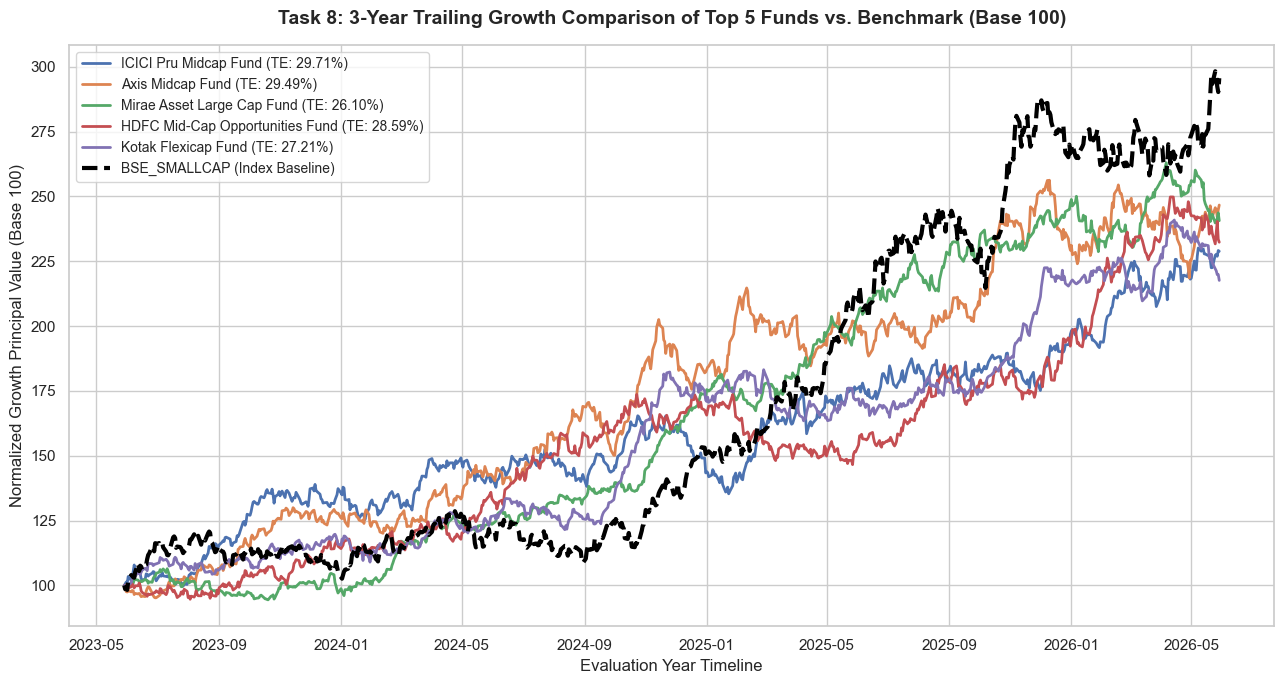

In [56]:
# 6. Generate Publication-Quality Visualizations
sns.set_theme(style="whitegrid")
plt.figure(figsize=(13, 7))

# Plot the top 5 funds performance path
for amfi_code in df_normalized_funds.columns:
    lbl = f"{legend_name_map[amfi_code]} (TE: {tracking_errors[amfi_code]:.2%})"
    sns.lineplot(data=df_normalized_funds, x=df_normalized_funds.index, y=amfi_code, label=lbl, linewidth=2)

# Superimpose the macro index benchmark as a distinct, heavy black dashed line layer
plt.plot(df_normalized_bench.index, df_normalized_bench[benchmark_col], label=f'{benchmark_col} (Index Baseline)', color='black', linewidth=3, linestyle='--')

# Chart fine-tuning parameters
plt.title("Task 8: 3-Year Trailing Growth Comparison of Top 5 Funds vs. Benchmark (Base 100)", weight='bold', fontsize=14, pad=15)
plt.xlabel("Evaluation Year Timeline", fontsize=12)
plt.ylabel("Normalized Growth Principal Value (Base 100)", fontsize=12)
plt.legend(loc='upper left', frameon=True, fontsize=10)
plt.tight_layout()

In [ ]:
# Save out high-res asset
output_chart_path = WORKSPACE_DIR / "outputs" / "charts" / "08_benchmark_comparison_chart.png"
output_chart_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_chart_path, dpi=300)
plt.show()

print("📌 --- ANNUALIZED TRACKING ERROR MATRIX ---")
for amfi_code in top_5_amfi:
    print(f"• {legend_name_map[amfi_code]:<35} | Tracking Error: {tracking_errors[amfi_code]:.4%}")

print(f"\n Benchmark chart saved perfectly to {output_chart_path}")

<Figure size 640x480 with 0 Axes>

📌 --- ANNUALIZED TRACKING ERROR MATRIX ---
• ICICI Pru Midcap Fund               | Tracking Error: 29.7141%
• Axis Midcap Fund                    | Tracking Error: 29.4914%
• Mirae Asset Large Cap Fund          | Tracking Error: 26.0968%
• HDFC Mid-Cap Opportunities Fund     | Tracking Error: 28.5921%
• Kotak Flexicap Fund                 | Tracking Error: 27.2123%

✅ Success:  complete! Benchmark chart saved perfectly to C:\Users\P LIKITH VARMA\OneDrive\Desktop\mutual_fund_analtics\mutual_fund_analytics_platform\outputs\charts\08_benchmark_comparison_chart.png
